# Buổi 6: Trực quan hóa và kể câu chuyện với dữ liệu

In [1]:
# nhúng thư viện matplotlib
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
df = pd.read_csv("spotify.csv")
df

,Date,Shape of You,Despacito,Something Just Like This,HUMBLE.,Unforgettable
0,2017-01-06,12287078,NaN,NaN,NaN,NaN
1,2017-01-07,13190270,NaN,NaN,NaN,NaN
2,2017-01-08,13099919,NaN,NaN,NaN,NaN
3,2017-01-09,14506351,NaN,NaN,NaN,NaN
4,2017-01-10,14275628,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
361,2018-01-05,4492978,3450315.0,2408365.0,2685857.0,2869783.0
362,2018-01-06,4416476,3394284.0,2188035.0,2559044.0,2743748.0
363,2018-01-07,4009104,3020789.0,1908129.0,2350985.0,2441045.0
364,2018-01-08,4135505,2755266.0,2023251.0,2523265.0,2622693.0


In [3]:
# Làm sạch dữ liệu:
# Đổi dữ liệu cột Date -> kiểu dữ liệu "datetime64"
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d")
df.dtypes

Date                        datetime64[ns]
Shape of You                         int64
Despacito                          float64
Something Just Like This           float64
HUMBLE.                            float64
Unforgettable                      float64
dtype: object

<Axes: xlabel='Date'>

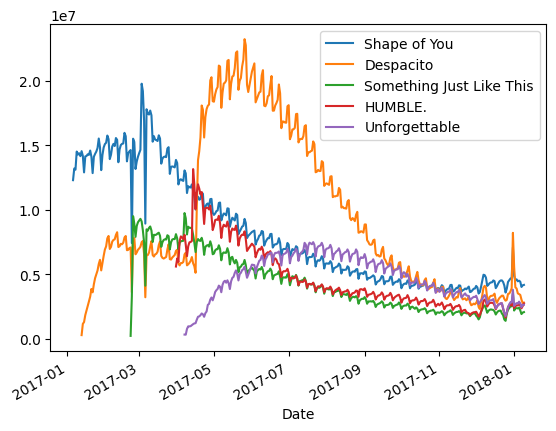

In [4]:
df.plot.line(x="Date")

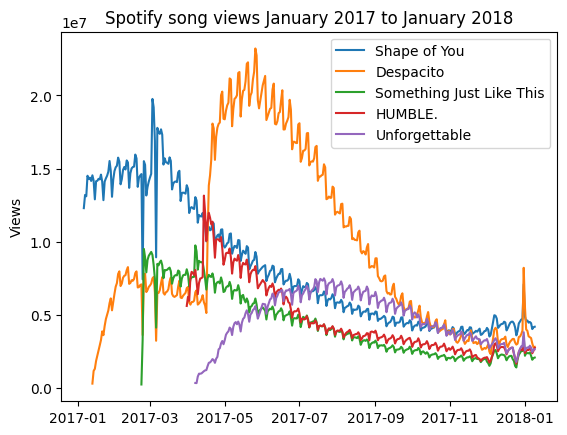

In [5]:
# Vẽ biểu đồ đường bằng pyplot
plt.Figure(figsize=(14,6)) # khởi tạo kích thước biểu đồ

df_line = df.set_index("Date") # giá trị dựa trên cột "Date"
plt.plot(df_line) # Vẽ line

plt.legend(df_line.columns) # chú thích
plt.ylabel("Views") # tên cột y
plt.title("Spotify song views January 2017 to January 2018") # tên tiêu đề

plt.show()

#### Line: để kết nối các điểm dữ liệu riêng lẻ. Biểu diễn xu hướng của mội chuỗi dữ liệu, đặc biệt dữ liệu theo thời gian.

### Sử lí file tỉ phú

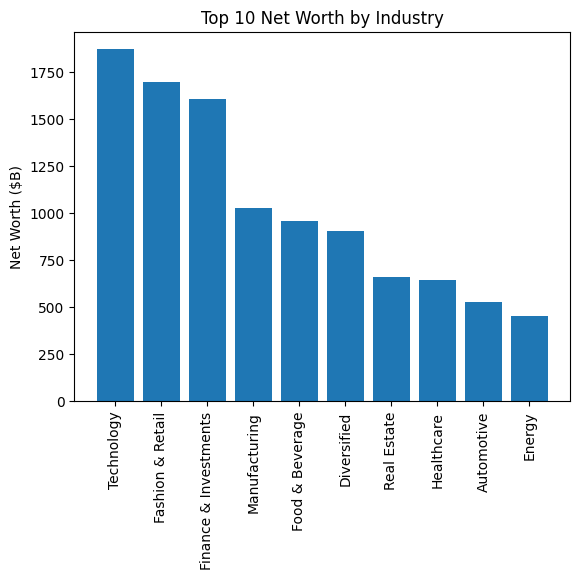

In [6]:
df_Billionaires = pd.read_csv("Billionaires.csv")

df_Billionaires["Net Worth"] = df_Billionaires["Net Worth"].apply(lambda x : x[1 : -1])
df_Billionaires["Net Worth"] = pd.to_numeric(df_Billionaires["Net Worth"])
df_industry = df_Billionaires[["Industry", "Net Worth"]].groupby("Industry").sum()
df_industry = df_industry.sort_values("Net Worth", ascending=False) # ascending = False -> giảm dần / = True -> tăng dần
df_industry
# Top 10 tổng tài sản theo lĩnh vực:
df_topindustry = df_industry[:10]
df_topindustry
plt.bar(x=df_topindustry.index, height=df_topindustry["Net Worth"])
plt.xticks(rotation=90)
plt.ylabel("Net Worth ($B)")
plt.title("Top 10 Net Worth by Industry")
plt.show()